# House Prices - Advanced Regression Techniques

## Deep Learning Lab 02

### Thông tin bài toán

- Dataset: House Prices - Advanced Regression Techniques
- Nguồn dữ liệu: Kaggle
- Mục tiêu: Dự đoán giá bán nhà (SalePrice)
- Loại bài toán: Regression
- Framework: PyTorch

### Thành viên nhóm

- Mai Thị Thúy An (Leader)
- Trần Đoàn Phương Quyên
- Nguyễn Thị Phương Thanh

### Mục tiêu thực hiện

- Tiền xử lý dữ liệu
- Xây dựng mô hình MLP bằng PyTorch
- Tinh chỉnh các siêu tham số (Hyperparameters)
- Đánh giá kết quả mô hình

# Import thư viện

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Load Dataset

In [2]:
train_df = pd.read_csv("../Dataset/train.csv")
test_df = pd.read_csv("../Dataset/test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)



Train shape: (1460, 81)
Test shape: (1459, 80)


In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [4]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

**NOTE: Test có thêm cột SalePrice**

#  Missing Values

## Train data

In [5]:
missing = train_df.isnull().sum()
missing = missing[missing > 0]
missing = missing.sort_values(ascending=False)
missing.head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

<Axes: >

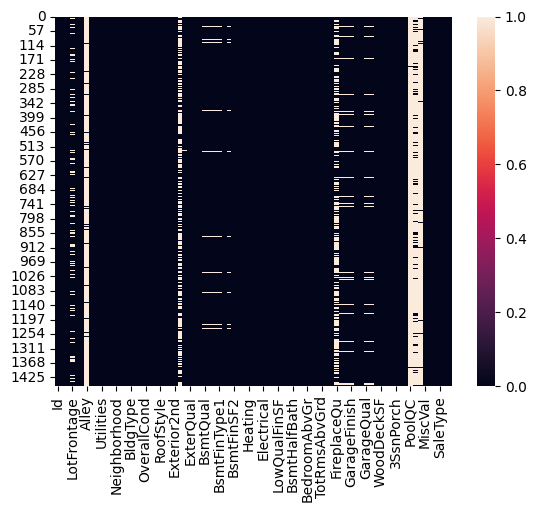

In [6]:
sns.heatmap(train_df.isnull()) 

**NOTE: Nhóm thiếu toàn là ko có hồ bơi, hẻm, hàng rào, garage, tầng hầm**

In [7]:
train_df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

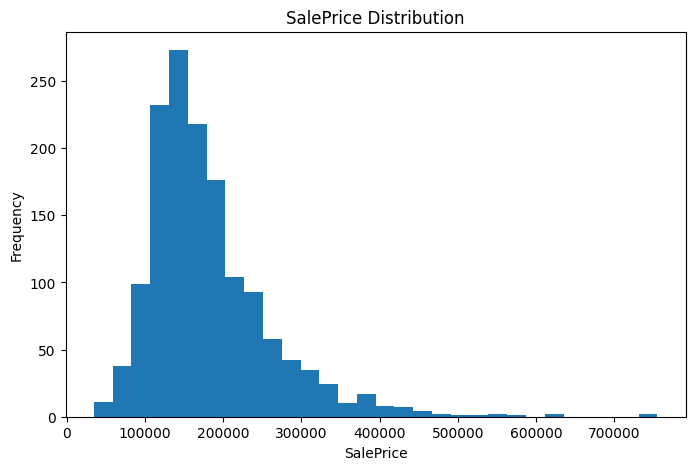

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(train_df["SalePrice"], bins=30)

plt.title("SalePrice Distribution")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")

plt.show()

## Test data

In [9]:
missing = test_df.isnull().sum()
missing = missing[missing > 0]
missing = missing.sort_values(ascending=False)
missing.head(20)

PoolQC          1456
MiscFeature     1408
Alley           1352
Fence           1169
MasVnrType       894
FireplaceQu      730
LotFrontage      227
GarageQual        78
GarageCond        78
GarageYrBlt       78
GarageFinish      78
GarageType        76
BsmtCond          45
BsmtQual          44
BsmtExposure      44
BsmtFinType1      42
BsmtFinType2      42
MasVnrArea        15
MSZoning           4
Functional         2
dtype: int64

<Axes: >

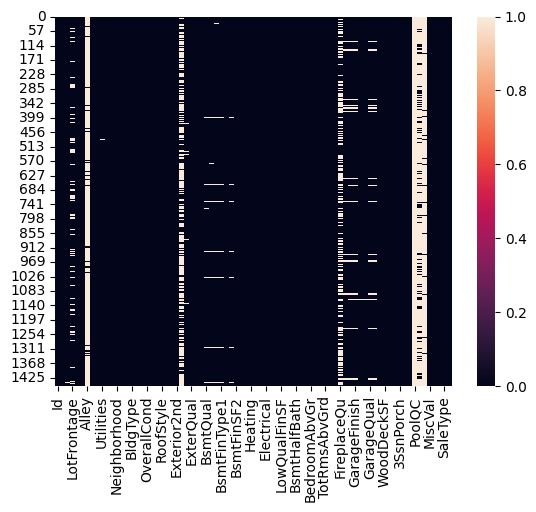

In [10]:
sns.heatmap(test_df.isnull()) 

# Handling Missing Values

## Train

In [11]:
cat_col_train = [
    'FireplaceQu',
    'GarageType',
    'GarageFinish',
    'MasVnrType',
    'BsmtQual',
    'BsmtCond',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2',
    'GarageQual',
    'GarageCond'
]

ncat_col_train = [
    'LotFrontage',
    'GarageYrBlt',
    'MasVnrArea'
]

for col in cat_col_train:
    train_df[col] = train_df[col].fillna(
        train_df[col].mode()[0]
    )

for col in ncat_col_train:
    train_df[col] = train_df[col].fillna(
        train_df[col].mean()
    )

In [12]:
train_df[
    cat_col_train + ncat_col_train
].isnull().sum()

FireplaceQu     0
GarageType      0
GarageFinish    0
MasVnrType      0
BsmtQual        0
BsmtCond        0
BsmtExposure    0
BsmtFinType1    0
BsmtFinType2    0
GarageQual      0
GarageCond      0
LotFrontage     0
GarageYrBlt     0
MasVnrArea      0
dtype: int64

## Test

In [13]:
cat_col_test = [
    'FireplaceQu', 'GarageType', 'GarageFinish', 'MasVnrType',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
    'BsmtFinType2', 'GarageQual', 'GarageCond', 'MSZoning',
    'Utilities', 'Exterior1st', 'Exterior2nd', 'KitchenQual',
    'Functional', 'SaleType'
]

ncat_col_test = [
    'LotFrontage', 'GarageYrBlt', 'MasVnrArea', 'BsmtFinSF1',
    'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath',
    'BsmtHalfBath', 'GarageCars', 'GarageArea'
]

for col in cat_col_test:
    test_df[col] = test_df[col].fillna(test_df[col].mode()[0])

for col in ncat_col_test:
    test_df[col] = test_df[col].fillna(test_df[col].mean())

In [14]:
test_df[
    cat_col_test + ncat_col_test
].isnull().sum()

FireplaceQu     0
GarageType      0
GarageFinish    0
MasVnrType      0
BsmtQual        0
BsmtCond        0
BsmtExposure    0
BsmtFinType1    0
BsmtFinType2    0
GarageQual      0
GarageCond      0
MSZoning        0
Utilities       0
Exterior1st     0
Exterior2nd     0
KitchenQual     0
Functional      0
SaleType        0
LotFrontage     0
GarageYrBlt     0
MasVnrArea      0
BsmtFinSF1      0
BsmtFinSF2      0
BsmtUnfSF       0
TotalBsmtSF     0
BsmtFullBath    0
BsmtHalfBath    0
GarageCars      0
GarageArea      0
dtype: int64

In [15]:
print(train_df.shape)
print(test_df.shape)

(1460, 81)
(1459, 80)


In [16]:
print('Id' in train_df.columns)

True


In [17]:
train_df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

## Drop Colunms

In [18]:
to_drop = ['Id', 'Alley', 'PoolQC', 'Fence', 'MiscFeature']

for k in to_drop:
    train_df.drop([k], axis=1, inplace=True)
    test_df.drop([k], axis=1, inplace=True)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (1460, 76)
Test shape: (1459, 75)


<Axes: >

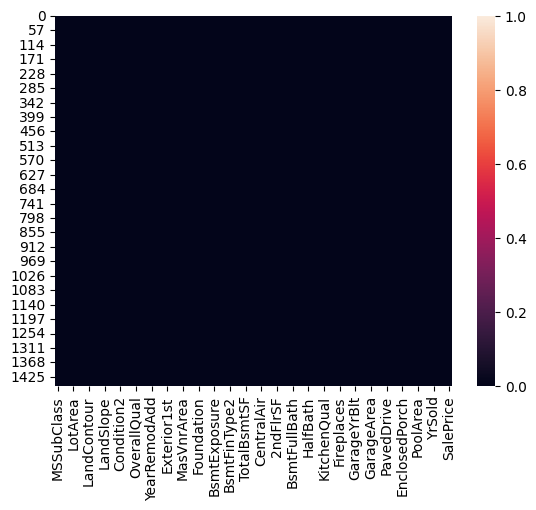

In [19]:
sns.heatmap(train_df.isnull()) 

<Axes: >

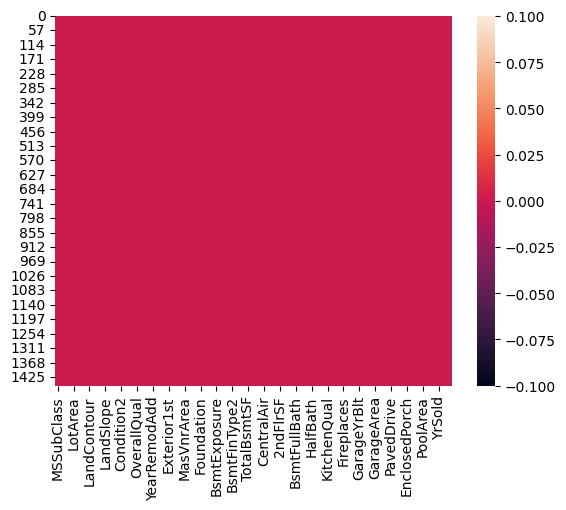

In [20]:
sns.heatmap(test_df.isnull()) 

In [21]:
train_df["Electrical"] = train_df["Electrical"].fillna(
    train_df["Electrical"].mode()[0]
)

In [22]:
all_cat_col = ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl',
'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir',
'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']
def cat_onehot_encoding(multicol):
    df_final = final_df
    i = 0
    for fields in multicol:
        print(fields)
        df1 = pd.get_dummies (final_df[fields], drop_first = True)
        final_df.drop([fields], axis=1, inplace = True)
        if i==0:
            df_final = df1.copy()
        else:
            df_final = pd.concat([df_final, df1], axis = 1)
        i=i+1

    df_final = pd.concat([final_df,df_final], axis=1)

    return df_final
final_df = pd.concat([train_df, test_df], axis=0)

final_df = cat_onehot_encoding(all_cat_col)

MSZoning
Street
LotShape
LandContour
Utilities
LotConfig
LandSlope
Neighborhood
Condition1
Condition2
BldgType
HouseStyle
RoofStyle
RoofMatl
Exterior1st
Exterior2nd
MasVnrType
ExterQual
ExterCond
Foundation
BsmtQual
BsmtCond
BsmtExposure
BsmtFinType1
BsmtFinType2
Heating
HeatingQC
CentralAir
Electrical
KitchenQual
Functional
FireplaceQu
GarageType
GarageFinish
GarageQual
GarageCond
PavedDrive
SaleType
SaleCondition


In [23]:
print(final_df.shape)

(2919, 236)


In [24]:
final_df=final_df.loc[:,~final_df.columns.duplicated()]
final_df.shape

(2919, 176)

In [25]:
df_train=final_df.iloc[:1460,:]
df_test=final_df.iloc[1460:,:]

df_test.drop(['SalePrice'], axis=1, inplace=True)

print("Train Shape:", df_train.shape)
print("Test Shape:", df_test.shape)

Train Shape: (1460, 176)
Test Shape: (1459, 175)


C:\Users\An Mai\AppData\Local\Temp\ipykernel_8116\2528689808.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test.drop(['SalePrice'], axis=1, inplace=True)


# Training Data

In [26]:
x_train=df_train.drop(['SalePrice'], axis=1)
y_train=df_train['SalePrice']

In [27]:
print(x_train.shape)
print(y_train.shape)

(1460, 175)
(1460,)


## Model 1: XGBoost

In [28]:
import xgboost as xgb

In [29]:
xgb_model = xgb.XGBRegressor()
print(xgb_model.fit(x_train, y_train))

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)


In [30]:
from sklearn.model_selection import RandomizedSearchCV

In [31]:
param = {
    'n_estimators': [100, 500, 900, 1100, 1500],
    'max_depth': [2, 3, 5, 10, 15],
    'learning_rate': [0.05, 0.1, 0.15, 0.2],
    'min_child_weight': [1, 2, 3, 4],
    'booster': ['gbtree', 'gblinear'],
    'base_score': [0.25, 0.5, 0.75, 1]
}

In [105]:
random= RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param,
    n_iter=10,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=2,
    return_train_score=True,
    random_state=42,
    n_jobs=1
)
print(random.fit(x_train, y_train))

Fitting 5 folds for each of 10 candidates, totalling 50 fits


e:\Code\Lib\site-packages\xgboost\training.py:183: UserWarning: [00:35:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "max_depth", "min_child_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END base_score=1, booster=gblinear, learning_rate=0.2, max_depth=10, min_child_weight=3, n_estimators=1500; total time=   2.0s


e:\Code\Lib\site-packages\xgboost\training.py:183: UserWarning: [00:35:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "max_depth", "min_child_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END base_score=1, booster=gblinear, learning_rate=0.2, max_depth=10, min_child_weight=3, n_estimators=1500; total time=   1.6s


...

[CV] END base_score=0.5, booster=gblinear, learning_rate=0.05, max_depth=3, min_child_weight=4, n_estimators=1100; total time=   1.0s


e:\Code\Lib\site-packages\xgboost\training.py:183: UserWarning: [00:37:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "max_depth", "min_child_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END base_score=0.5, booster=gblinear, learning_rate=0.05, max_depth=3, min_child_weight=4, n_estimators=1100; total time=   1.2s


e:\Code\Lib\site-packages\xgboost\training.py:183: UserWarning: [00:37:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "max_depth", "min_child_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END base_score=0.5, booster=gblinear, learning_rate=0.05, max_depth=3, min_child_weight=4, n_estimators=1100; total time=   1.3s
RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=0.75, booster='gbtree',
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constr...
               

In [33]:
print(random.best_estimator_)

XGBRegressor(base_score=0.75, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=4, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1100,
             n_jobs=None, num_parallel_tree=None, ...)


In [34]:
from numpy import nan
xgb_model = xgb.XGBRegressor(base_score=0.75, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=4, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1100,
             n_jobs=None, num_parallel_tree=None)

In [35]:
print(xgb_model.fit(x_train, y_train))

XGBRegressor(base_score=0.75, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=4, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1100,
             n_jobs=None, num_parallel_tree=None, ...)


In [36]:
import joblib
joblib.dump(xgb_model, 'xgb_model.pkl')

import os
os.path.exists('xgb_model.pkl')

True

### Prediction

In [37]:
pred_xgb=xgb_model.predict(df_test)
print(pred_xgb.shape)

(1459,)


### Submission

In [38]:
sub_df=pd.read_csv('E:\\SGU\\Nam4DH\\Deep Learning\\DeepLearning_Team\\Week2\\Lab02\\Dataset\\sample_submission.csv')
sub_df['SalePrice']=pred_xgb
sub_df.to_csv("submission.csv", index=False)

## Model 2: Decision Tree

In [39]:
from sklearn.tree import DecisionTreeRegressor

In [40]:
dt_model=DecisionTreeRegressor()
print(dt_model.fit(x_train, y_train))

DecisionTreeRegressor()


In [ ]:
params = {
    'max_depth': [3, 5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}
random= RandomizedSearchCV(
    estimator=dt_model,
    param_distributions=params,
    n_iter=20,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=2
)
print(random.fit(x_train, y_train))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
RandomizedSearchCV(cv=5, estimator=DecisionTreeRegressor(), n_iter=20,
                   n_jobs=-1,
                   param_distributions={'max_depth': [3, 5, 10, 15, 20, None],
                                        'max_features': [None, 'sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4, 8],
                                        'min_samples_split': [2, 5, 10, 20]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)


In [42]:
print(random.fit(x_train, y_train))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
RandomizedSearchCV(cv=5, estimator=DecisionTreeRegressor(), n_iter=20,
                   n_jobs=-1,
                   param_distributions={'max_depth': [3, 5, 10, 15, 20, None],
                                        'max_features': [None, 'sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4, 8],
                                        'min_samples_split': [2, 5, 10, 20]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)


In [43]:
print(random.best_params_)
print(random.best_score_)

{'min_samples_split': 5, 'min_samples_leaf': 8, 'max_features': None, 'max_depth': 15}
-1380536606.2814083


In [44]:
best_dt = random.best_estimator_

### Prediction

In [45]:
pred_dt = best_dt.predict(df_test)
print(pred_dt.shape)

(1459,)


### Submission

In [46]:
sub_df=pd.read_csv('E:\\SGU\\Nam4DH\\Deep Learning\\DeepLearning_Team\\Week2\\Lab02\\Dataset\\sample_submission.csv')
sub_df['SalePrice']=pred_dt
sub_df.to_csv("submission.csv", index=False)

# Model 3: Random Forest

In [47]:
from sklearn.ensemble import RandomForestRegressor

In [48]:
rf_model = RandomForestRegressor()
print(rf_model.fit(x_train, y_train))

RandomForestRegressor()


In [ ]:
params = {
    'n_estimators': [100, 300, 500, 700, 1000],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}
random = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=params,
    n_iter=20,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=2
)
print(random.fit(x_train, y_train))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(), n_iter=20,
                   n_jobs=-1,
                   param_distributions={'max_depth': [5, 10, 15, 20, None],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 300, 500, 700,
                                                         1000]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)


In [50]:
print(random.fit(x_train, y_train))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(), n_iter=20,
                   n_jobs=-1,
                   param_distributions={'max_depth': [5, 10, 15, 20, None],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 300, 500, 700,
                                                         1000]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)


In [51]:
print(random.best_params_)
print(random.best_score_)

{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
-919346453.3982594


In [52]:
best_rf = random.best_estimator_

### Prediction

In [53]:
pred_rf = best_rf.predict(df_test)
print(pred_rf.shape)

(1459,)


### Submission

In [54]:
sub_df=pd.read_csv('E:\\SGU\\Nam4DH\\Deep Learning\\DeepLearning_Team\\Week2\\Lab02\\Dataset\\sample_submission.csv')
sub_df['SalePrice']=pred_rf
sub_df.to_csv("submission.csv", index=False)

# Model 4: Linear Regression

In [55]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

print(lr_model.fit(x_train, y_train))

LinearRegression()


In [ ]:
params = {
    'fit_intercept':[True, False],
    'positive':[True, False]
}
random = RandomizedSearchCV(
    estimator=lr_model,
    param_distributions=params,
    n_iter=4,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=1,
    verbose=2
)

In [67]:
print(random.fit(x_train, y_train))

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV] END ..................fit_intercept=True, positive=True; total time=   0.0s
[CV] END ..................fit_intercept=True, positive=True; total time=   0.0s
[CV] END ..................fit_intercept=True, positive=True; total time=   0.0s
[CV] END ..................fit_intercept=True, positive=True; total time=   0.0s
[CV] END ..................fit_intercept=True, positive=True; total time=   0.0s
[CV] END .................fit_intercept=True, positive=False; total time=   0.0s
[CV] END .................fit_intercept=True, positive=False; total time=   0.0s
[CV] END .................fit_intercept=True, positive=False; total time=   0.0s
[CV] END .................fit_intercept=True, positive=False; total time=   0.0s
[CV] END .................fit_intercept=True, positive=False; total time=   0.0s
[CV] END .................fit_intercept=False, positive=True; total time=   0.0s
[CV] END .................fit_intercept=False, po

In [68]:
print(random.best_params_)
print(random.best_score_)

{'positive': True, 'fit_intercept': False}
-1239031525.3341966


In [69]:
best_lr = random.best_estimator_

In [60]:
print(lr_model.fit(x_train, y_train))

LinearRegression()


In [62]:
pred_lr = lr_model.predict(df_test)
print(pred_lr.shape)

(1459,)


## Sub

In [63]:
sub_df=pd.read_csv('E:\\SGU\\Nam4DH\\Deep Learning\\DeepLearning_Team\\Week2\\Lab02\\Dataset\\sample_submission.csv')
sub_df['SalePrice']=pred_lr
sub_df.to_csv("submission.csv", index=False)

# Model 5: Gradient Boosting Regressor

In [70]:
from sklearn.ensemble import GradientBoostingRegressor

In [71]:
gbr_model = GradientBoostingRegressor()

In [ ]:
params = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [2, 3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
random = RandomizedSearchCV(
    estimator=gbr_model,
    param_distributions=params,
    n_iter=5,
    cv=3,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

In [74]:
print(random.fit(x_train, y_train))

Fitting 3 folds for each of 5 candidates, totalling 15 fits
RandomizedSearchCV(cv=3, estimator=GradientBoostingRegressor(), n_iter=5,
                   n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [2, 3, 5, 7],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)


In [75]:
print("Best parameters:", random.best_params_)
print("Best score:", random.best_score_)

Best parameters: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 2, 'learning_rate': 0.2}
Best score: -689924264.3571419


In [76]:
best_gbr = random.best_estimator_

### Pred

In [77]:
pred_gbr = best_gbr.predict(df_test)

print(pred_gbr.shape)

(1459,)


### Sub

In [79]:
sub_df=pd.read_csv('E:\\SGU\\Nam4DH\\Deep Learning\\DeepLearning_Team\\Week2\\Lab02\\Dataset\\sample_submission.csv')
sub_df['SalePrice']=pred_gbr
sub_df.to_csv("submission.csv", index=False)

# Model 6: SVR

In [ ]:
from sklearn.svm import SVR

svr = SVR()

params = {
    'kernel':['linear','rbf'],
    'C':[0.1,1,10,100],
    'gamma':['scale','auto']
}
random = RandomizedSearchCV(
    estimator=svr,
    param_distributions=params,
    n_iter=2,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=1
)
print(random.fit(x_train,y_train))

RandomizedSearchCV(cv=3, estimator=SVR(), n_iter=2, n_jobs=1,
                   param_distributions={'C': [0.1, 1, 10, 100],
                                        'gamma': ['scale', 'auto'],
                                        'kernel': ['linear', 'rbf']},
                   scoring='neg_mean_squared_error')


In [82]:
print("Best parameters:", random.best_params_)
print("Best score:", random.best_score_)

Best parameters: {'kernel': 'linear', 'gamma': 'scale', 'C': 1}
Best score: -1688133369.831005


In [83]:
best_svr = random.best_estimator_

### Pre

In [86]:
pred_svr = best_svr.predict(df_test)
print(pred_svr.shape)

(1459,)


### Sub

In [87]:
sub_df=pd.read_csv('E:\\SGU\\Nam4DH\\Deep Learning\\DeepLearning_Team\\Week2\\Lab02\\Dataset\\sample_submission.csv')
sub_df['SalePrice']=pred_svr
sub_df.to_csv("submission.csv", index=False)

# ANN 

In [90]:
x_train.shape

(1460, 175)

In [91]:
df_test.shape

(1459, 175)

In [93]:
from torch.utils.data import TensorDataset, DataLoader

In [117]:
x_tr, x_val, y_tr, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=42
)

In [125]:
x_tr = x_tr.astype(float)
x_val = x_val.astype(float)

x_tr = torch.tensor(x_tr.astype(float).values, dtype=torch.float32)
x_val = torch.tensor(x_val.astype(float).values, dtype=torch.float32)

y_tr = torch.tensor(y_tr.values, dtype=torch.float32).reshape(-1,1)
y_val = torch.tensor(y_val.values, dtype=torch.float32).reshape(-1,1)

In [126]:
print(type(x_tr))
print(type(x_val))
print(x_tr.shape)

<class 'torch.Tensor'>
<class 'torch.Tensor'>
torch.Size([1168, 175])


In [127]:
train_dataset = TensorDataset(x_tr, y_tr)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

In [128]:
class HousePriceANN(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(175, 50),
            nn.ReLU(),

            nn.Linear(50, 25),
            nn.ReLU(),

            nn.Linear(25, 50),
            nn.ReLU(),

            nn.Linear(50, 1)
        )
    def forward(self, x):
        return self.network(x)

In [129]:
model = HousePriceANN()

In [130]:
criterion = nn.MSELoss()

In [131]:
optimizer = optim.Adamax(
    model.parameters(),
    lr=0.001
)

In [132]:
epochs = 100
for epoch in range(epochs):
    model.train()
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [10/100], Loss: 33263329280.0000
Epoch [20/100], Loss: 2127664384.0000
Epoch [30/100], Loss: 5013324800.0000
Epoch [40/100], Loss: 2777377280.0000
Epoch [50/100], Loss: 2985432832.0000
Epoch [60/100], Loss: 1994973312.0000
Epoch [70/100], Loss: 1579739648.0000
Epoch [80/100], Loss: 3856184320.0000
Epoch [90/100], Loss: 2946620416.0000
Epoch [100/100], Loss: 4604766720.0000


In [133]:
model.eval()
with torch.no_grad():
    val_pred = model(x_val)

    rmse = np.sqrt(
        mean_squared_error(
            y_val.numpy(),
            val_pred.numpy()
        )
    )
print("Validation RMSE:", rmse)

Validation RMSE: 44584.457202033984


In [141]:
x_test_tensor = torch.tensor(
    df_test.values,
    dtype=torch.float32
)

### Pred

In [142]:
x_test_tensor = torch.tensor(
    df_test.values,
    dtype=torch.float32
)
x_test_tensor = torch.tensor(
    df_test.values,
    dtype=torch.float32
)

In [144]:
model.eval()

with torch.no_grad():
    pred_ann = model(x_test_tensor)

pred_ann = pred_ann.numpy().flatten()

print(pred_ann.shape)

(1459,)


In [145]:
sub_df = pd.read_csv(
    r'E:\SGU\Nam4DH\Deep Learning\DeepLearning_Team\Week2\Lab02\Dataset\sample_submission.csv'
)
sub_df['SalePrice'] = pred_ann

sub_df.to_csv(
    'submission_ann.csv',
    index=False
)

DONE